In [16]:
import pandas as pd

# Create dataset
data = {
    "Outlook": ["Sunny", "Sunny", "Overcast", "Rainy", "Rainy", "Rainy", "Overcast",
                "Sunny", "Sunny", "Rainy", "Sunny", "Overcast", "Overcast", "Rainy"],
    "Humidity": ["High", "High", "High", "High", "Normal", "Normal", "Normal",
                 "High", "Normal", "Normal", "Normal", "High", "Normal", "High"],
    "Windy": [False, True, False, False, False, True, True,
              False, False, False, True, True, False, True],
    "Play": ["No", "No", "Yes", "Yes", "Yes", "No", "Yes",
             "No", "Yes", "Yes", "Yes", "Yes", "Yes", "No"]
}

df = pd.DataFrame(data)


In [17]:
df

,Outlook,Humidity,Windy,Play
0,Sunny,High,False,No
1,Sunny,High,True,No
2,Overcast,High,False,Yes
3,Rainy,High,False,Yes
4,Rainy,Normal,False,Yes
5,Rainy,Normal,True,No
6,Overcast,Normal,True,Yes
7,Sunny,High,False,No
8,Sunny,Normal,False,Yes
9,Rainy,Normal,False,Yes


In [18]:
from sklearn.preprocessing import LabelEncoder

In [19]:
encoder=LabelEncoder()

In [20]:
		
df['Outlook']=encoder.fit_transform(df['Outlook'])
df['Humidity']=encoder.fit_transform(df['Humidity'])
df['Windy']=encoder.fit_transform(df['Windy'])
df['Play']=encoder.fit_transform(df['Play'])

In [21]:
df

,Outlook,Humidity,Windy,Play
0,2,0,0,0
1,2,0,1,0
2,0,0,0,1
3,1,0,0,1
4,1,1,0,1
5,1,1,1,0
6,0,1,1,1
7,2,0,0,0
8,2,1,0,1
9,1,1,0,1


In [22]:
x=df[['Outlook','Humidity','Windy']]

In [23]:
x

,Outlook,Humidity,Windy
0,2,0,0
1,2,0,1
2,0,0,0
3,1,0,0
4,1,1,0
5,1,1,1
6,0,1,1
7,2,0,0
8,2,1,0
9,1,1,0


In [24]:
y=df['Play']

In [25]:
y

0     0
1     0
2     1
3     1
4     1
5     0
6     1
7     0
8     1
9     1
10    1
11    1
12    1
13    0
Name: Play, dtype: int64

In [28]:
from sklearn.model_selection import train_test_split

In [30]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [31]:
from sklearn.tree import DecisionTreeClassifier

In [50]:
tee=DecisionTreeClassifier(criterion='entropy')

In [51]:
tee.fit(x_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [52]:
tee.predict(x_test)

array([1, 1, 0])

In [53]:
x_test

,Outlook,Humidity,Windy
9,1,1,0
11,0,0,1
0,2,0,0


In [54]:
df

,Outlook,Humidity,Windy,Play
0,2,0,0,0
1,2,0,1,0
2,0,0,0,1
3,1,0,0,1
4,1,1,0,1
5,1,1,1,0
6,0,1,1,1
7,2,0,0,0
8,2,1,0,1
9,1,1,0,1


In [55]:
tee.score(x_test,y_test)

1.0

In [56]:
from sklearn import tree

[Text(0.4, 0.9, 'x[0] <= 0.5\nentropy = 0.946\nsamples = 11\nvalue = [4, 7]'),
 Text(0.3, 0.7, 'entropy = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.35, 0.8, 'True  '),
 Text(0.5, 0.7, 'x[1] <= 0.5\nentropy = 1.0\nsamples = 8\nvalue = [4, 4]'),
 Text(0.45, 0.8, '  False'),
 Text(0.3, 0.5, 'x[0] <= 1.5\nentropy = 0.811\nsamples = 4\nvalue = [3, 1]'),
 Text(0.2, 0.3, 'x[2] <= 0.5\nentropy = 1.0\nsamples = 2\nvalue = [1, 1]'),
 Text(0.1, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.4, 0.3, 'entropy = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.7, 0.5, 'x[2] <= 0.5\nentropy = 0.811\nsamples = 4\nvalue = [1, 3]'),
 Text(0.6, 0.3, 'entropy = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.8, 0.3, 'x[0] <= 1.5\nentropy = 1.0\nsamples = 2\nvalue = [1, 1]'),
 Text(0.7, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.9, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]')]

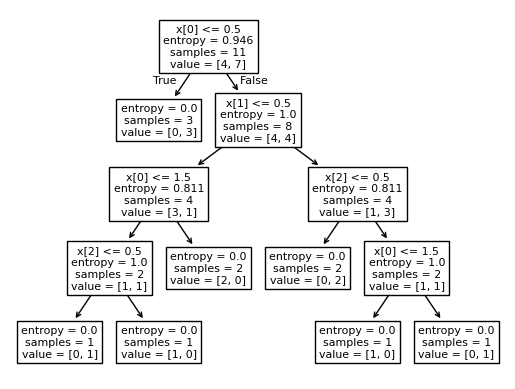

In [57]:
tree.plot_tree(tee)